In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import precision_recall_curve

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

1,383,526 observations, 133 colonnes


In [3]:
def clean_feature_names(df):
    """Remplace les caractères spéciaux dans les noms de colonnes par des underscores."""
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)

Modèle : LGBMClassifier
AUC-ROC   : 0.4208  — aire sous la courbe ROC
AUC-PR    : 0.0142  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.0589  — taux de résiliants détectés
Précision : 0.0091  — part de vrais résiliants parmi les alertes
F1        : 0.0157  — équilibre recall/précision
F2        : 0.0280  — pénalise davantage les faux négatifs
MCC       : -0.0232  — robuste au déséquilibre des classes
Brier     : 0.0940  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       0.98      0.88      0.93    375637
           1       0.01      0.06      0.02      6706

    accuracy                           0.87    382343
   macro avg       0.50      0.47      0.47    382343
weighted avg       0.96      0.87      0.91    382343



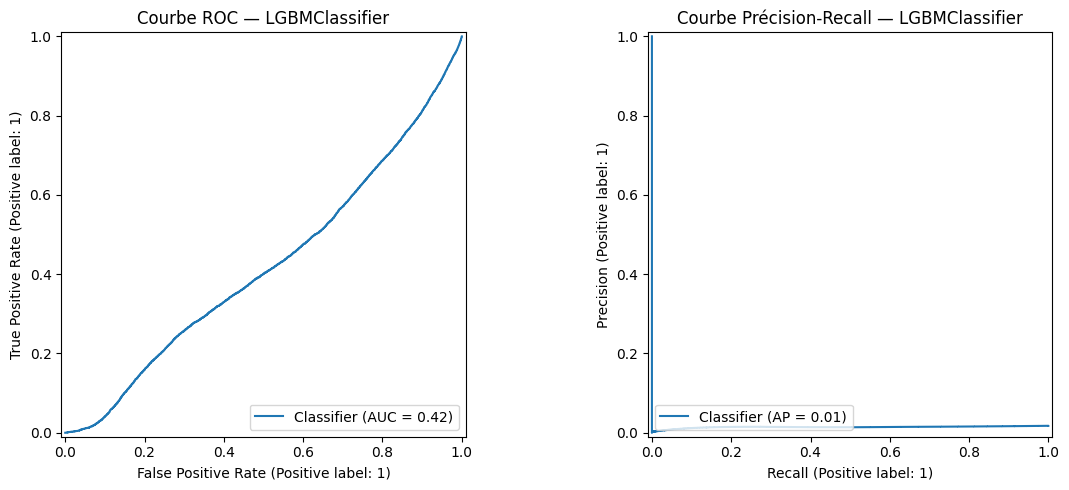

Modèle sauvegardé dans models/lightgbm.pkl


'models/lightgbm.pkl'

In [5]:
cols_insee = [col for col in df.columns if 'indice' in col or 'chomage' in col]
features_sans_insee = [f for f in FEATURES if f not in cols_insee]

x_train, x_test, y_train, y_test = split_data(df, features=features_sans_insee)
x_train_lgbm = clean_feature_names(x_train)
x_test_lgbm  = clean_feature_names(x_test)

model_sans_insee = LGBMClassifier(
    subsample=1.0,
    reg_lambda=0.1,
    reg_alpha=0.5,
    num_leaves=31,
    n_estimators=500,
    min_child_samples=50,
    max_depth=-1,
    learning_rate=0.01,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

model_sans_insee.fit(x_train_lgbm, y_train)
metrics_sans_insee = evaluate(model_sans_insee, x_test_lgbm, y_test)
save_model(model_sans_insee, 'lightgbm')

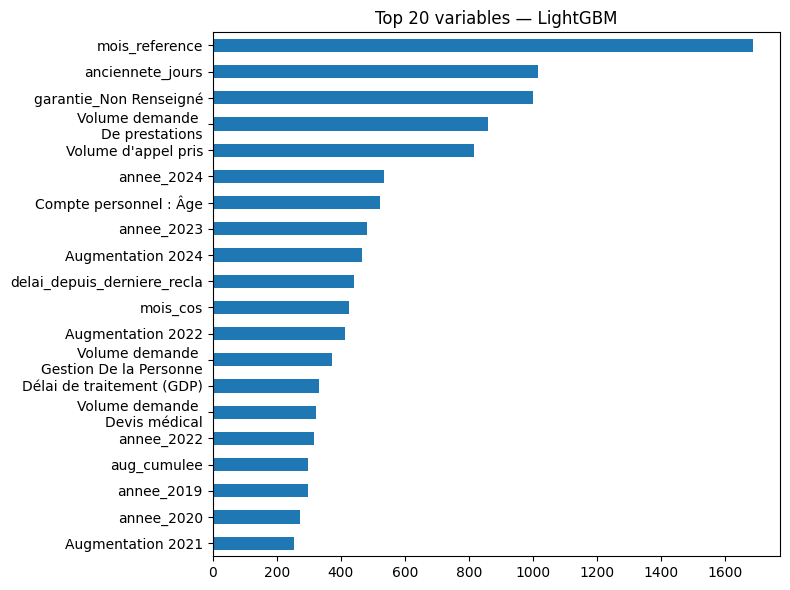

In [7]:
importances = pd.Series(model_sans_insee.feature_importances_, index=features_sans_insee)
importances.sort_values(ascending=False).head(20).plot(
    kind='barh', figsize=(8, 6)
)
plt.title('Top 20 variables — LightGBM')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()